Create patient specific graphs 

Load the static graph first 

In [1]:
import pandas as pd
import os

os.chdir('/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/')

protein_list_df = pd.read_csv('./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv') 

protein_list = set(protein_list_df['Gene'].tolist())

In [2]:
len(protein_list)

1406

In [3]:
proteomics_df = pd.read_csv('./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/expression_df_imputed_RF_QRILC.csv')

if 'proteins' not in proteomics_df.columns:
    raise ValueError("Expected column 'Genes' in proteomics.csv")

# Filter only proteins that exist in the protein list
filtered_proteomics_df = proteomics_df[proteomics_df['proteins'].isin(protein_list)]
filtered_proteomics_df.shape

(1406, 82)

In [4]:
import pandas as pd

# Load the node index mapping file
node_mapping_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv")  # Columns: New_Node_Index, <other_col>, Gene

# Load proteomics data
proteomics_df_graph = filtered_proteomics_df
# Merge on 'Genes' from proteomics and 'Gene' from mapping
proteomics_df_graph = proteomics_df_graph.merge(node_mapping_df[['New_Node_Index', 'Gene']], 
                                    how="left", 
                                    left_on="proteins", 
                                    right_on="Gene")

# Drop redundant 'Gene' column
proteomics_df_graph = proteomics_df_graph.drop(columns=["Gene"])

# Rename 'New_Node_Index' to 'node_index' for clarity
proteomics_df_graph = proteomics_df_graph.rename(columns={"New_Node_Index": "node_index"})

# Move 'node_index' to the first column
cols = ["node_index"] + [col for col in proteomics_df_graph.columns if col != "node_index"]
proteomics_df_graph = proteomics_df_graph[cols]

# Sort by node_index to align with edge_index
proteomics_df_graph = proteomics_df_graph.sort_values(by="node_index").reset_index(drop=True)

# Save to CSV (optional)
proteomics_df_graph.to_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/proteomics_with_node_index.csv", index=False)

# Display first few rows
print(proteomics_df_graph.head(10))


   node_index proteins         1          2          3          4          5  \
0           0    MAPK1  7.802514  10.202104   9.953741   9.398615   8.750083   
1           1    SUGT1  7.399674   9.787278   7.674280   8.868291   7.480898   
2           2     RBX1  8.135661   9.263705   9.463213   8.738964   9.040746   
3           3     PEPD  6.965637   8.238970   7.633213   8.197812   7.967809   
4           4    EEF1G  8.658194  10.967774  12.913033  10.452811  12.098784   
5           5     VTA1  5.405084   8.468171   9.322748   8.312569  10.084401   
6           6     LSM5  6.610383   8.416186  10.032527   7.744039  11.051090   
7           7    PFDN1  6.563723   9.448795  10.136892   8.829930  10.266574   
8           8    PSMD5  7.072155   8.612993   9.984705   8.199514  10.079000   
9           9      RAN  9.607943  10.209488  10.652225   9.618730  10.522399   

          60          6          7  ...        95         29        37  \
0   8.618377   8.981996  10.487751  ...  6.93

Create patient graphs now ...

In [5]:
import pandas as pd
import torch
from torch_geometric.data import Data
import os

# Load the static graph (edges)
edges_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/final_edge_index_RF_QRILC.csv")  # Columns: Source, Target, Edge_Weight

# Load the node index mapping
node_mapping_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv")  # Columns: New_Node_Index, Gene

if proteomics_df_graph['node_index'].is_monotonic_increasing and proteomics_df_graph['node_index'].min() == 0:
    print("Node indices are in a continuous, monotonically increasing order from 0 to the max.")
else:
    print("Node indices are not continuous or not in increasing order.")

# Step 4: Map gene names to node indices using the node_mapping_df
gene_to_node_index = dict(zip(node_mapping_df['Gene'], node_mapping_df['New_Node_Index']))

# Step 5: Create the edge_index and edge_attr for the static graph
edge_index = torch.tensor([
    edges_df['Source_Node'].values,  # Source nodes
    edges_df['Target_Node'].values   # Target nodes
], dtype=torch.long)

# Edge weights (assuming 'Edge_Weight' is a column in your edges_df)
edge_attr = torch.tensor(edges_df['Edge_Weight'].values, dtype=torch.float)

# Step 6: Prepare the patient graphs
patient_graphs = {}

# Iterate over patients (excluding the 'Genes' column)
for patient in proteomics_df_graph.columns[2:]:
    # Extract node features (expression values for this patient)
    x = torch.tensor(proteomics_df_graph[patient].values, dtype=torch.float).view(-1, 1)  # Shape: (num_nodes, 1)
    
    # Create PyG Data object
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    
    # Store the graph for each patient
    patient_graphs[patient] = data

# Optionally, print the first few graphs for verification
for patient, graph in patient_graphs.items():
    print(f"Patient: {patient}, Graph Data: {graph}")

output_dir = "./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/PatientGraphs/"
os.makedirs(output_dir, exist_ok=True)

for patient, graph in patient_graphs.items():
    torch.save(graph, os.path.join(output_dir, f"{patient}_graph.pt"))

print("Patient-specific graphs have been created successfully.")


/home/vascul/vsayyalasomayajula/my-scratch/miniconda3/envs/GNN/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/vascul/vsayyalasomayajula/PythonEnvs/GNN/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/vascul/vsayyalasomayajula/my-scratch/miniconda3/envs/GNN/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /scratch/vascul/vsayyalasomayajula/PythonEnvs/GNN/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


Node indices are in a continuous, monotonically increasing order from 0 to the max.
Patient: 1, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 2, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 3, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 4, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 5, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 60, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 6, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 7, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 8, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 9, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr=[85916])
Patient: 62, Graph Data: Data(x=[1406, 1], edge_index=[2, 85916], edge_attr

/home/vascul/vsayyalasomayajula/tmp/ipykernel_2085241/3767484327.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  edge_index = torch.tensor([


Patient-specific graphs have been created successfully.


Optional - to add correlation coefficients as edge property


In [6]:
import numpy as np
import pandas as pd

protein_data = pd.read_csv('./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/expression_df_imputed_RF_QRILC.csv')
protein_data = protein_data.iloc[:, 1:]
# Compute the correlation matrix for proteins (across all patients)
correlation_matrix = protein_data.corr(method='spearman')  # For Spearman correlation; use 'pearson' for Pearson correlation
print(correlation_matrix.iloc[1,0])

0.36276355884924766


In [7]:
import pandas as pd
import torch
from torch_geometric.data import Data

edges_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/final_edge_index_RF_QRILC.csv")  

node_mapping_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv")  


if proteomics_df_graph['node_index'].is_monotonic_increasing and proteomics_df_graph['node_index'].min() == 0:
    print("Node indices are in a continuous, monotonically increasing order from 0 to the max.")
else:
    print("Node indices are not continuous or not in increasing order.")

gene_to_node_index = dict(zip(node_mapping_df['Gene'], node_mapping_df['New_Node_Index']))

edge_index = torch.tensor([
    edges_df['Source_Node'].values, 
    edges_df['Target_Node'].values   
], dtype=torch.long)

edge_attr = torch.tensor(edges_df['Edge_Weight'].values, dtype=torch.float).view(-1, 1)  

patient_graphs = {}

for patient in proteomics_df_graph.columns[2:]:

    x = torch.tensor(proteomics_df_graph[patient].values, dtype=torch.float).view(-1, 1)  
    
    edge_correlations = []
    num_proteins = correlation_matrix.shape[0]  
    
    for i, j in zip(edge_index[0], edge_index[1]):
        if i < num_proteins and j < num_proteins:  
            correlation_value = correlation_matrix.iloc[int(i), int(j)]  
            edge_correlations.append(correlation_value)
        else:
            edge_correlations.append(0)  


    edge_correlations_tensor = torch.tensor(edge_correlations, dtype=torch.float).view(-1, 1)
    
    
    edge_attr_combined = torch.cat([edge_attr, edge_correlations_tensor], dim=1)  

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr_combined)
    
    patient_graphs[patient] = data

output_dir = "./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/PatientGraphs/Correlations/"
os.makedirs(output_dir, exist_ok=True)

for patient, graph in patient_graphs.items():
    torch.save(graph, os.path.join(output_dir, f"{patient}_graph.pt"))

print("Patient-specific graphs with edge attributes have been created successfully.")


Node indices are in a continuous, monotonically increasing order from 0 to the max.
Patient-specific graphs with edge attributes have been created successfully.


Inspect one graph

In [8]:
print(patient_graphs.keys())


dict_keys(['1', '2', '3', '4', '5', '60', '6', '7', '8', '9', '62', '10', '11', '21', '12', '13', '63', '14', '15', '23', '16', '17', '64', '18', '19', '26', '20', '22', '24', '25', '30', '53', '32', '33', '67', '34', '36', '68', '38', '39', '41', '69', '43', '91', '45', '70', '47', '92', '48', '49', '71', '50', '93', '54', '55', '94', '73', '74', '80', '81', '96', '75', '85', '86', '88', '89', '72', '82', '35', '78', '77', '95', '29', '37', '79', '61', '66', '31', '76', '83', '87'])


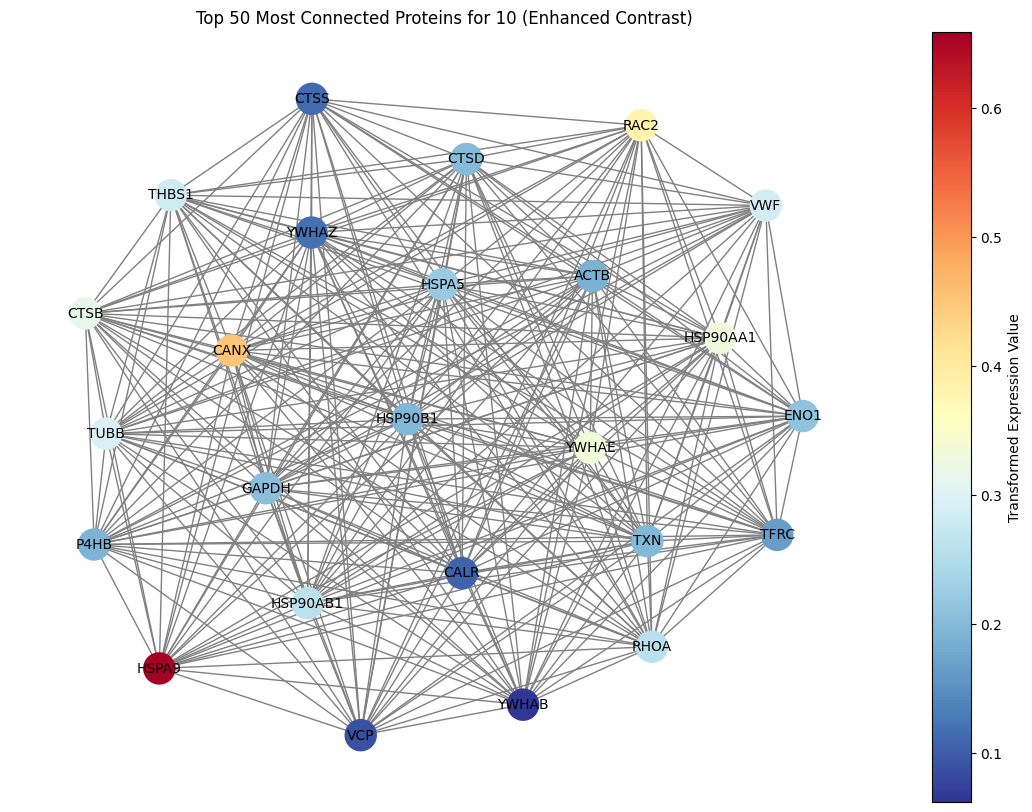

In [9]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
import numpy as np
from sklearn.preprocessing import MinMaxScaler

patient = "10"  
graph = patient_graphs[patient]

node_mapping_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv")
gene_to_node_index = dict(zip(node_mapping_df['New_Node_Index'], node_mapping_df['Gene']))

# Extract and normalize node features
node_features = graph.x.numpy().flatten()
scaler = MinMaxScaler()
node_features_normalized = scaler.fit_transform(node_features.reshape(-1, 1)).flatten()

# Apply a non-linear transformation for better contrast
node_features_normalized = np.power(node_features_normalized, 2)  # Exaggerate differences

# Create a NetworkX graph from the edge index
G = nx.Graph()
edge_index_np = graph.edge_index.numpy()
for i, j in zip(edge_index_np[0], edge_index_np[1]):
    G.add_edge(i, j)

# Get the top 50 most connected nodes
node_degrees = dict(G.degree())
top_50_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)[:25]
top_50_subgraph = G.subgraph(top_50_nodes)

# Extract features for top 50 nodes
node_colors = node_features_normalized[top_50_nodes]

# Set node labels
node_labels = {node: gene_to_node_index[node] for node in top_50_nodes}

# Plot the graph
fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(top_50_subgraph, seed=42, k=0.1, iterations=100)

# Draw graph with a high-contrast colormap
nx.draw(top_50_subgraph, pos, with_labels=True, labels=node_labels, node_size=500, 
        node_color=node_colors, cmap="RdYlBu_r", font_size=10, ax=ax, edge_color="gray")

# Create a colorbar with adjusted contrast
sm = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=plt.Normalize(vmin=np.min(node_colors), vmax=np.max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Transformed Expression Value")

plt.title(f"Top 50 Most Connected Proteins for {patient} (Enhanced Contrast)")
plt.show()


Creating a GIF of all patient graphs 

In [10]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from PIL import Image
import imageio
import os

node_mapping_df = pd.read_csv("./PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/finalnode_info_with_Genes_RF_QRILC.csv")  
gene_to_node_index = dict(zip(node_mapping_df['New_Node_Index'], node_mapping_df['Gene']))

all_features = []
for patient in patient_graphs.keys():
    graph = patient_graphs[patient]
    all_features.append(graph.x.numpy().flatten())
all_features = np.concatenate(all_features)

scaler = MinMaxScaler()
scaler.fit(all_features.reshape(-1, 1))

gif_path = "/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/PatientGraphs/patient_graphs_overlay.gif"
frames = []
temp_dir = "temp_frames"
os.makedirs(temp_dir, exist_ok=True)

for i, patient in enumerate(patient_graphs.keys()):
    graph = patient_graphs[patient]

    node_features = graph.x.numpy().flatten()
    node_features_normalized = scaler.transform(node_features.reshape(-1, 1)).flatten()
    node_features_normalized = np.power(node_features_normalized, 2)

    G = nx.Graph()
    edge_index_np = graph.edge_index.numpy()
    for i, j in zip(edge_index_np[0], edge_index_np[1]):
        G.add_edge(i, j)
    
    node_degrees = dict(G.degree())
    top_50_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)[:50]
    top_50_subgraph = G.subgraph(top_50_nodes)

    node_colors = node_features_normalized[top_50_nodes]
    
    node_labels = {node: gene_to_node_index[node] for node in top_50_nodes}

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(top_50_subgraph, seed=42, k=0.1, iterations=100)
    
    nodes = nx.draw_networkx_nodes(top_50_subgraph, pos, node_size=500,
                                 node_color=node_colors, cmap="RdYlBu_r",
                                 vmin=0, vmax=1, ax=ax)
    nx.draw_networkx_edges(top_50_subgraph, pos, edge_color="gray", ax=ax)
    nx.draw_networkx_labels(top_50_subgraph, pos, labels=node_labels, font_size=10, ax=ax)

    sm = plt.cm.ScalarMappable(cmap="RdYlBu_r", norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Transformed Expression Value (Global Scale)")
    
    plt.title(f"Top 50 Most Connected Proteins for {patient}")
    
    frame_path = os.path.join(temp_dir, f"frame_{i:03d}.png")
    plt.savefig(frame_path, bbox_inches='tight', dpi=100)
    plt.close()
    
    # Add to frames list
    frames.append(imageio.imread(frame_path))

# Create GIF (adjust fps as needed)
imageio.mimsave(gif_path, frames, fps=1, loop=0)

# Clean up temporary frames
for frame in os.listdir(temp_dir):
    os.remove(os.path.join(temp_dir, frame))
os.rmdir(temp_dir)

print(f"GIF saved to {gif_path}")

/home/vascul/vsayyalasomayajula/tmp/ipykernel_2085241/3621421734.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))
/home/vascul/vsayyalasomayajula/tmp/ipykernel_2085241/3621421734.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))
/home/vascul/vsayyalasomayajula/tmp/ipykernel_2085241/3621421734.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2

GIF saved to /home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/PreprocessingScripts/CohortSpecificImpute/PatientGraphs/patient_graphs_overlay.gif


In [27]:
def make_vertical_expression_integration_visual(graph, gene_to_node_index, patient="10", top_k=25, seed=42,
                                                save_path=None, dpi=300, vertical_shift=2.5):
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import networkx as nx
    import numpy as np

    # Plasma features
    plasma_features = graph.x.numpy().flatten()
    plasma_norm = (plasma_features - plasma_features.min()) / (plasma_features.max() - plasma_features.min())
    plasma_norm = np.power(plasma_norm, 2)

    # Tissue = perturbed plasma
    rng = np.random.default_rng(seed)
    tissue_norm = plasma_norm * (0.8 + 0.1 * rng.random(len(plasma_norm)))
    tissue_norm = np.clip(tissue_norm, 0, 1)

    # Build plasma subgraph
    G = nx.Graph()
    edge_index_np = graph.edge_index.numpy()
    for i, j in zip(edge_index_np[0], edge_index_np[1]):
        G.add_edge(i, j)
    node_degrees = dict(G.degree())
    top_nodes = sorted(node_degrees, key=node_degrees.get, reverse=True)[:top_k]
    plasma_subgraph = G.subgraph(top_nodes)

    # Build integrated graph
    integrated = nx.Graph()
    for n in top_nodes:
        integrated.add_node(f"plasma_{n}", type="plasma", value=plasma_norm[n])
        integrated.add_node(f"tissue_{n}", type="tissue", value=tissue_norm[n])
    for i, j in plasma_subgraph.edges():
        integrated.add_edge(f"plasma_{i}", f"plasma_{j}", type="plasma")
        integrated.add_edge(f"tissue_{i}", f"tissue_{j}", type="tissue")
    for n in top_nodes:
        integrated.add_edge(f"plasma_{n}", f"tissue_{n}", type="cross")

    # Layout: plasma top, tissue bottom (increase vertical gap)
    pos = {}
    plasma_pos = nx.spring_layout(plasma_subgraph, seed=seed)
    for n, (x, y) in plasma_pos.items():
        pos[f"plasma_{n}"] = np.array([x, y+vertical_shift])   # higher
        pos[f"tissue_{n}"] = np.array([x, y-vertical_shift])   # lower

    # Node groups
    plasma_nodes = [n for n in integrated.nodes() if integrated.nodes[n]["type"]=="plasma"]
    tissue_nodes = [n for n in integrated.nodes() if integrated.nodes[n]["type"]=="tissue"]
    plasma_vals = [integrated.nodes[n]["value"] for n in plasma_nodes]
    tissue_vals = [integrated.nodes[n]["value"] for n in tissue_nodes]

    # Colormaps (plasma reversed for contrast)
    plasma_cmap = plt.cm.Blues_r
    tissue_cmap = plt.cm.Reds

    fig, ax = plt.subplots(figsize=(9,12))

    # Edges
    plasma_edges = [(u,v) for u,v,d in integrated.edges(data=True) if d["type"]=="plasma"]
    tissue_edges = [(u,v) for u,v,d in integrated.edges(data=True) if d["type"]=="tissue"]
    cross_edges  = [(u,v) for u,v,d in integrated.edges(data=True) if d["type"]=="cross"]

    nx.draw_networkx_edges(integrated, pos, edgelist=plasma_edges, edge_color="lightblue", width=1, ax=ax)
    nx.draw_networkx_edges(integrated, pos, edgelist=tissue_edges, edge_color="lightcoral", width=1, ax=ax)
    nx.draw_networkx_edges(integrated, pos, edgelist=cross_edges, edge_color="gray", style="dashed", width=1, ax=ax)

    # Plasma nodes
    nx.draw_networkx_nodes(integrated, pos, nodelist=plasma_nodes,
                           node_color=plasma_vals, cmap=plasma_cmap, vmin=0, vmax=1,
                           edgecolors="blue", linewidths=2, node_size=500, ax=ax)
    # Tissue nodes
    nx.draw_networkx_nodes(integrated, pos, nodelist=tissue_nodes,
                           node_color=tissue_vals, cmap=tissue_cmap, vmin=0, vmax=1,
                           edgecolors="red", linewidths=2, node_size=500, ax=ax)

    # Labels
    labels = {n: gene_to_node_index[int(n.split("_")[1])] 
              for n in integrated.nodes() if int(n.split("_")[1]) in gene_to_node_index}
    nx.draw_networkx_labels(integrated, pos, labels=labels, font_size=8, ax=ax)

    plt.title(f"Integrated Plasma–Tissue Graph (Patient {patient})")
    plt.axis("off")

    # Colorbars on both sides
    sm1 = mpl.cm.ScalarMappable(cmap=plasma_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm1.set_array([])
    cbar1 = plt.colorbar(sm1, ax=ax, fraction=0.03, pad=0.15, location="left")
    cbar1.set_label("Plasma Expression (0–1)")

    sm2 = mpl.cm.ScalarMappable(cmap=tissue_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm2.set_array([])
    cbar2 = plt.colorbar(sm2, ax=ax, fraction=0.03, pad=0.15, location="right")
    cbar2.set_label("Tissue Expression (0–1)")

    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure to {save_path}")

    plt.show()


Saved figure to /home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/patient10_integrated_graph.png


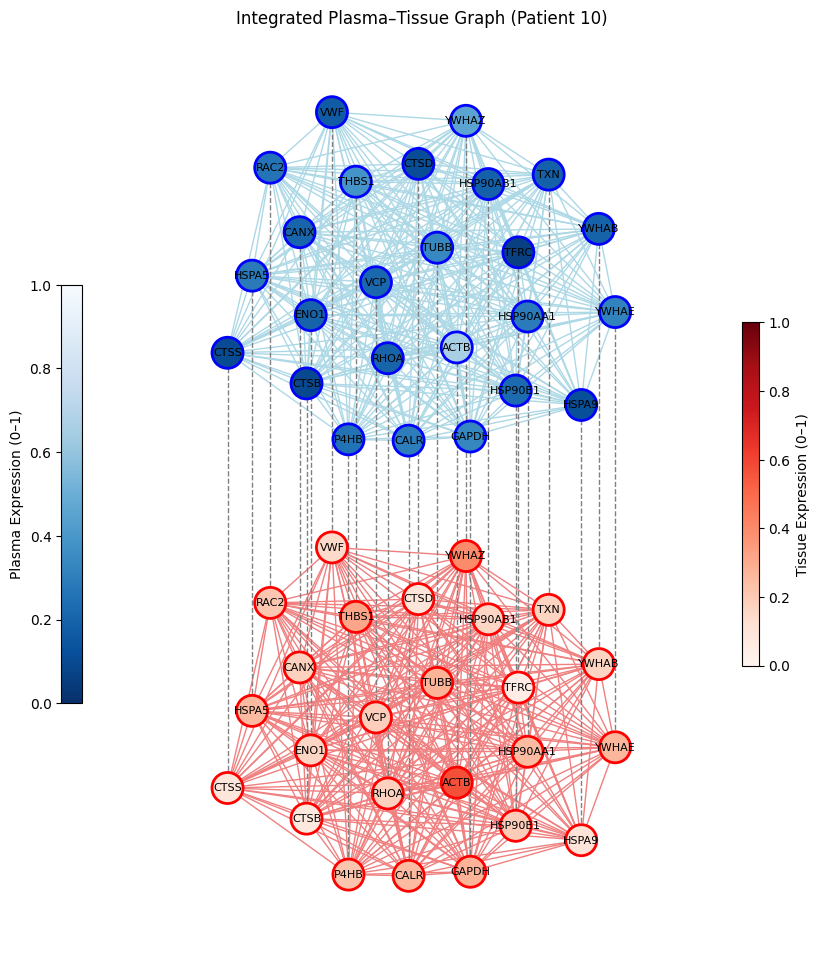

In [30]:

make_vertical_expression_integration_visual(
    graph=patient_graphs["10"],
    gene_to_node_index=gene_to_node_index,
    patient="10",
    top_k=25,
    save_path="/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/patient10_integrated_graph.png",
    dpi=600,  # high resolution
    vertical_shift=1.2  # increases the gap between plasma and tissue layers
)



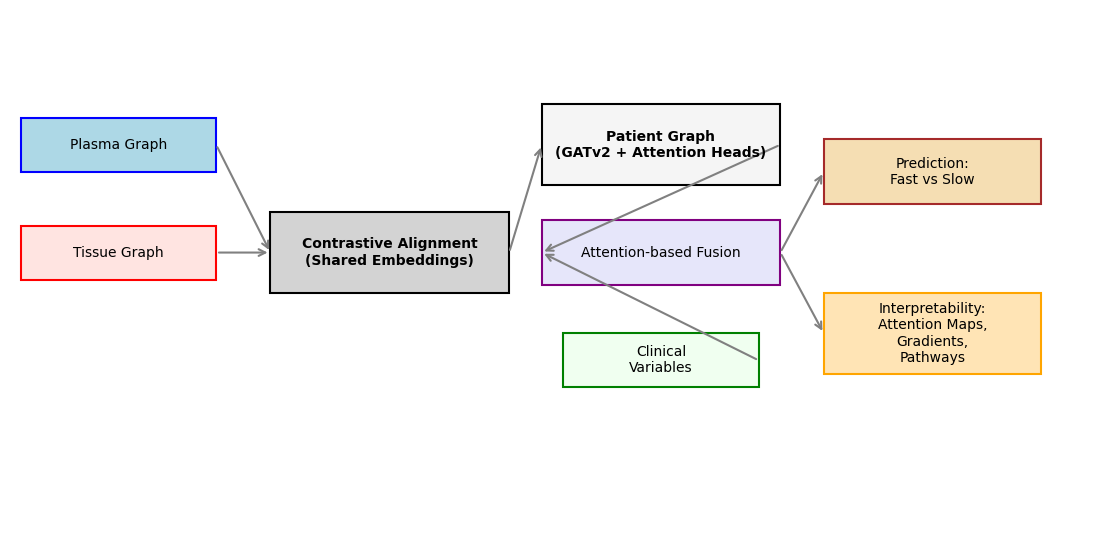

Saved Slide 2 framework visual as SVG to /home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/slide2_framework.svg


In [36]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

def draw_box(ax, center, width, height, text, facecolor, edgecolor="black", fontsize=10, weight="normal"):
    x, y = center
    box = Rectangle((x - width/2, y - height/2), width, height,
                    edgecolor=edgecolor, facecolor=facecolor, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, fontweight=weight)
    return (x, y, width, height)

def connect_boxes(ax, box1, box2, color="gray"):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    arrow = FancyArrowPatch((x1 + w1/2, y1), (x2 - w2/2, y2),
                            arrowstyle="->", color=color, mutation_scale=12, linewidth=1.5)
    ax.add_patch(arrow)

def make_slide2_svg(save_path="slide2_framework.svg"):
    fig, ax = plt.subplots(figsize=(14,7))
    ax.axis("off")

    # Column x coords
    col_x = [0.1, 0.35, 0.6, 0.85]
    row_y = [0.75, 0.55, 0.35]

    # --- Inputs ---
    plasma = draw_box(ax, (col_x[0], row_y[0]), 0.18, 0.1, "Plasma Graph", "lightblue", "blue")
    tissue = draw_box(ax, (col_x[0], row_y[1]), 0.18, 0.1, "Tissue Graph", "mistyrose", "red")
    clinical = draw_box(ax, (col_x[2], row_y[2]), 0.18, 0.1, "Clinical\nVariables", "honeydew", "green")

    # --- Alignment ---
    align = draw_box(ax, (col_x[1], 0.55), 0.22, 0.15,
                     "Contrastive Alignment\n(Shared Embeddings)",
                     "lightgray", "black", fontsize=10, weight="bold")

    connect_boxes(ax, plasma, align)
    connect_boxes(ax, tissue, align)

    # --- Patient Graph Encoder ---
    gnn = draw_box(ax, (col_x[2], row_y[0]), 0.22, 0.15,
                   "Patient Graph\n(GATv2 + Attention Heads)",
                   "whitesmoke", "black", fontsize=10, weight="bold")
    connect_boxes(ax, align, gnn)

    # --- Fusion Layer ---
    fusion = draw_box(ax, (col_x[2], 0.55), 0.22, 0.12,
                      "Attention-based Fusion", "lavender", "purple")
    connect_boxes(ax, gnn, fusion)
    connect_boxes(ax, clinical, fusion)

    # --- Outputs ---
    pred = draw_box(ax, (col_x[3], 0.7), 0.2, 0.12,
                    "Prediction:\nFast vs Slow", "wheat", "brown")
    interp = draw_box(ax, (col_x[3], 0.4), 0.2, 0.15,
                      "Interpretability:\nAttention Maps,\nGradients,\nPathways",
                      "moccasin", "orange")

    connect_boxes(ax, fusion, pred)
    connect_boxes(ax, fusion, interp)

    # Save as SVG (editable)
    plt.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved Slide 2 framework visual as SVG to {save_path}")


# === EXECUTION ===
make_slide2_svg(
    save_path="/home/vascul/vsayyalasomayajula/my-rdisk/r-divb/venkat/Proteomics/PlasmaAAA/slide2_framework.svg"
)
